Original data shape: (178, 13)
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Mean after scaling (~0): [ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]
Std after scaling (~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

PCA FROM SCRATCH

Covariance matrix:
 [[ 1.006  0.095  0.213 -0.312  0.272  0.291  0.238 -0.157  0.137  0.549
  -0.072  0.073  0.647]
 [ 0.095  1.006  0.165  0.29  -0.055 -0.337 -0.413  0.295 -0.222  0.25
  -0.564 -0.371 -0.193]
 [ 0.213  0.165  1.006  0.446  0.288  0.13   0.116  0.187  0.01   0.26
  -0.075  0.004  0.225]
 [-0.312  0.29   0.446  1.006 -0.084 -0.323 -0.353  0.364 -0.198  0.019
  -0.276 -0.278 -0.443]
 [ 0.272 -0.055  0.288 -0.084  1.006  0.216  0.197 -0.258  0.238  0.201
   0.056  0.066  0.396]
 [ 0.291 -0.337  0.13  -0.323  0.216  1.006  0.869 -0.452  0.616 -0.055
   0.436  

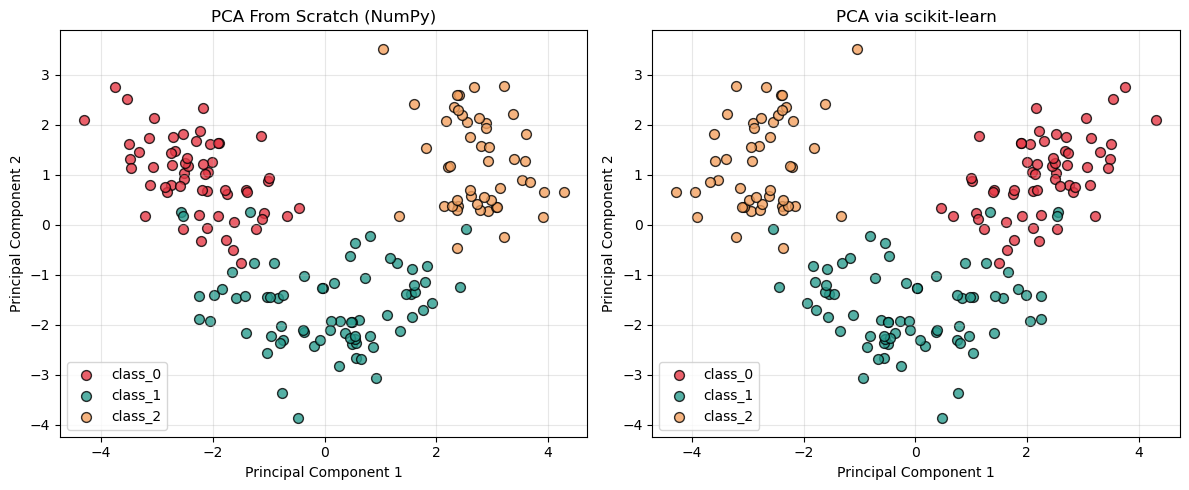

In [5]:
"""
PCA Laboratory Demonstration
============================
This script demonstrates Principal Component Analysis (PCA) in two ways:
  1. Implemented from scratch using NumPy (to understand the math)
  2. Using scikit-learn's PCA class (the practical, production way)

Dataset: The classic Iris dataset (4 features, 150 samples, 3 classes)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

# -----------------------------------------------------------------------
# STEP 1: Load the dataset
# -----------------------------------------------------------------------
iris = load_wine()
X = iris.data                # shape (150, 4) -> 4 features
y = iris.target              # class labels (0, 1, 2)
feature_names = iris.feature_names

print("Original data shape:", X.shape)
print("Feature names:", feature_names)

# -----------------------------------------------------------------------
# STEP 2: Standardize the data (mean = 0, std = 1)
# PCA is affected by scale, so features must be standardized first.
# -----------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nMean after scaling (~0):", np.round(X_scaled.mean(axis=0), 3))
print("Std after scaling (~1):", np.round(X_scaled.std(axis=0), 3))

# -----------------------------------------------------------------------
# STEP 3A: PCA FROM SCRATCH (using NumPy)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA FROM SCRATCH")
print("=" * 60)

# 1. Compute the covariance matrix of the standardized data
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance matrix:\n", np.round(cov_matrix, 3))

# 2. Compute eigenvalues and eigenvectors of the covariance matrix
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# 3. Sort eigenvalues (and corresponding eigenvectors) in descending order
sorted_idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

print("\nEigenvalues (sorted):", np.round(eigen_values, 3))

# 4. Compute explained variance ratio
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("Explained variance ratio:", np.round(explained_variance_ratio, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(explained_variance_ratio[:2]), 3))

# 5. Select top k eigenvectors (k=2) to form the projection matrix
k = 50
projection_matrix = eigen_vectors[:, :k]

# 6. Project the standardized data onto the new subspace
X_pca_scratch = X_scaled.dot(projection_matrix)
print("\nTransformed data shape (from scratch):", X_pca_scratch.shape)

# -----------------------------------------------------------------------
# STEP 3B: PCA USING SCIKIT-LEARN (practical approach)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("PCA USING SCIKIT-LEARN")
print("=" * 60)

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative variance (first 2 components):",
      np.round(np.sum(pca.explained_variance_ratio_), 3))
print("Transformed data shape (sklearn):", X_pca_sklearn.shape)

# -----------------------------------------------------------------------
# STEP 4: Visualize the result
# -----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#e63946", "#2a9d8f", "#f4a261"]
target_names = iris.target_names

for ax, data, title in zip(
    axes,
    [X_pca_scratch, X_pca_sklearn],
    ["PCA From Scratch (NumPy)", "PCA via scikit-learn"],
):
    for i, target_name in enumerate(target_names):
        ax.scatter(
            data[y == i, 0], data[y == i, 1],
            label=target_name, color=colors[i], alpha=0.8, edgecolor="k", s=50
        )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig("/home/claude/pca_iris_result.png", dpi=150)
print("\nPlot saved as pca_iris_result.png")

# -----------------------------------------------------------------------
# STEP 5: Sanity check - both methods should give (near) identical variance
# -----------------------------------------------------------------------
assert np.allclose(
    sorted(explained_variance_ratio[:2]),
    sorted(pca.explained_variance_ratio_),
    atol=1e-6,
), "Mismatch between scratch and sklearn implementations!"
print("\nSanity check passed: scratch implementation matches scikit-learn.")